<a href="https://colab.research.google.com/github/SayraIbarra/E50A-E01/blob/main/Proyecto_Mineria_Datos_Luz_Inteligente_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto Minería de Datos  
#Reconocimiento de Voz: **Luz Inteligente 🎤 💡**
  
**Grupo:** 8:00–9:00 PM  
**Fecha de entrega:** 25 de mayo de 2026  

## Integrantes
1. Integrante 1: 178774 - Ricardo Macías Varela
2. Integrante 2: 178678 - José Rodrigo Bravo Llanas  
3. Integrante 3: 178396 - Daniel Gil Gonzalez
4. Integrante 4: 177935 - Ramos Torralba Jonathan Guadalupe
---

## Resumen del proyecto
El objetivo es construir un modelo de red neuronal densa capaz de reconocer dos comandos de voz:

- **“encender luz”** → salida esperada: `Luz Encendida`
- **“apagar luz”** → salida esperada: `Luz Apagada`

Para ello se procesan audios grabados por alumnos, se extraen características MFCC, se normalizan los datos y se entrenan diferentes arquitecturas de redes neuronales densas para comparar resultados.


# Índice

1. [Introducción teórica](#introducción-teórica)  
2. [Configuración del entorno](#configuración-del-entorno)  
3. [Organización del dataset](#organización-del-dataset)  
4. [Exploración y validación de audios](#exploración-y-validación-de-audios)  
5. [Extracción de características MFCC](#extracción-de-características-mfcc)  
6. [División de datos](#división-de-datos)  
7. [Normalización](#normalización)  
8. [Construcción del modelo](#construcción-del-modelo)  
9. [Experimentación y tuning](#experimentación-y-tuning)  
10. [Evaluación del mejor modelo](#evaluación-del-mejor-modelo)  
11. [Simulación de salida](#simulación-de-salida)  
12. [Prueba ciega con voz del profesor](#prueba-ciega-con-voz-del-profesor)  
13. [Guardado del modelo](#guardado-del-modelo)  
14. [Conclusiones](#conclusiones)  

# Introducción teórica

## Procesamiento de audio

Una señal de audio es una onda que cambia con el tiempo. Para que una computadora pueda analizarla, el sonido se representa como una secuencia de valores numéricos. En este proyecto, cada grabación de voz se carga con una frecuencia de muestreo fija y se transforma en características numéricas.

Como los audios pueden tener distinta duración, volumen o cantidad de silencio, se aplica un flujo de preprocesamiento:

1. Cargar el audio.
2. Convertirlo a mono.
3. Usar la misma frecuencia de muestreo.
4. Recortar silencios excesivos.
5. Ajustar todos los audios a una duración fija.
6. Extraer características MFCC.
7. Normalizar los valores.

## MFCC

Los **MFCC** son coeficientes usados frecuentemente en tareas de reconocimiento de voz porque resumen información relevante del timbre y la forma espectral del sonido. En lugar de usar directamente la onda de audio, convertimos cada grabación en una matriz de características.

En este proyecto se usan MFCC porque permiten transformar una señal de voz en datos más adecuados para una red neuronal.

## Redes neuronales densas

Una red neuronal densa está formada por capas de neuronas donde cada neurona se conecta con las neuronas de la capa anterior. En este proyecto se usa una arquitectura `Sequential` con:

- Capa de entrada.
- Capa `Flatten` para convertir la matriz MFCC en un vector.
- Una o más capas densas ocultas.
- Capa de salida con activación `sigmoid`.

Como el problema tiene dos clases, se usa:

- **Función de pérdida:** `binary_crossentropy`
- **Métrica:** `accuracy`
- **Salida:** una probabilidad entre 0 y 1

Interpretación:

- Si la predicción es mayor a `0.5` → **Luz Encendida**
- Si la predicción es menor o igual a `0.5` → **Luz Apagada**


# Configuración del entorno

En esta sección se instalan e importan las librerías necesarias.

Librerías principales:

- `librosa`: procesamiento de audio y extracción de MFCC.
- `numpy`: operaciones numéricas.
- `tensorflow.keras`: construcción y entrenamiento del modelo.
- `pandas`: manejo de tablas.
- `matplotlib`: gráficas.
- `sklearn`: división de datos y métricas.


In [ ]:
# Instalación de dependencias principales
# En Google Colab, muchas de estas librerías ya vienen instaladas.
# Se dejan estas instrucciones para asegurar compatibilidad.

!pip -q install librosa soundfile


In [ ]:
# Importación de librerías

import os
import re
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

# Montar Google Drive

El dataset esta guardado en Google Drive para que Colab pueda acceder a los audios.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Organización del dataset

Se crea una carpeta con esta estructura:

```text
Mi unidad/
└── Proyecto_Luz_Inteligente/
    ├── dataset/
    │   ├── encender_luz/
    │   │   ├── alumno01_rep01_encender.wav
    │   │   ├── alumno01_rep02_encender.mp3
    │   │   └── ...
    │   │
    │   └── apagar_luz/
    │       ├── alumno01_rep01_apagar.wav
    │       ├── alumno01_rep02_apagar.mp3
    │       └── ...
    │
    ├── prueba_ciega/
    │   └── audio_profesor.wav
    │
    └── resultados/
```

## Reglas recomendadas para las grabaciones

- Grabar con celular, pero en un lugar sin música ni ruido fuerte.
- Grabar la frase completa, sin cortarla.
- Duración recomendada: entre 1 y 3 segundos.
- Mantener una distancia similar al micrófono.
- Grabar más de una repetición por frase si está permitido.
- Usar exactamente las frases: **“encender luz”** y **“apagar luz”**.
- Evitar nombres de archivo confusos.

In [ ]:
# Configuración de rutas ajustada a la realidad del Drive
PROJECT_NAME = "Proyecto_Luz_Inteligente"
PROJECT_DIR = f"/content/drive/MyDrive/{PROJECT_NAME}"

# Actualizado: los audios están dentro de la subcarpeta 'Librosa'
DATASET_DIR = os.path.join(PROJECT_DIR, "Librosa")
RESULTS_DIR = os.path.join(PROJECT_DIR, "resultados")
BLIND_TEST_DIR = os.path.join(PROJECT_DIR, "prueba_ciega")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(BLIND_TEST_DIR, exist_ok=True)

# Ajustamos los nombres de las clases a los nombres de tus carpetas
CLASSES = {
    "apagarluz": 0,
    "encenderluz": 1
}

LABEL_TO_ACTION = {
    0: "Luz Apagada",
    1: "Luz Encendida"
}

print("Carpeta del proyecto:", PROJECT_DIR)
print("Buscando audios en:", DATASET_DIR)
print("Clases detectadas:", list(CLASSES.keys()))

Carpeta del proyecto: /content/drive/MyDrive/Proyecto_Luz_Inteligente
Buscando audios en: /content/drive/MyDrive/Proyecto_Luz_Inteligente/Librosa
Clases detectadas: ['apagarluz', 'encenderluz']


### Acceso a Carpeta Compartida


In [ ]:
import os

# Listar las carpetas en tu Drive para encontrar el nombre del acceso directo
mi_unidad_path = "/content/drive/MyDrive/"
if os.path.exists(mi_unidad_path):
    print("Carpetas encontradas en tu Drive:")
    print(os.listdir(mi_unidad_path))
else:
    print("Google Drive no parece estar montado correctamente.")

Carpetas encontradas en tu Drive:
['nose.gdoc', 'Qué es el cerebro.docx', 'Qué es el cerebro.gdoc', 'Classroom', 'EJERCICIOS ELEMENTOS DE LA ORACIÓN.gdoc', 'Simulación CENEVAL.gdoc', 'Certificado para empleados.gslides', 'Portfolio.gslides', 'Excursión.gslides', 'Tu gran idea.gslides', 'avicii-waiting-for-love-instrumental.mp3', 'Minijuego-Tipos de pensamiento.png', 'Actividad - Tipos de pensamiento.pdf', 'Tipos de pensamiento.pdf', 'Reglas ortográficas.gform', 'Minijuego Cit. APA.png', 'Actividad - Ragnarok.png', 'Minijuego - Teoria.png', 'Corrección.gform', 'Minijuego - tutorial.png', 'Minijuego - teoria - referencias APA.png', 'Minijuego2 - teoria - referencias APA.png', 'Actividad - Práctica.png', 'Dinamita - Práctica.png', 'Educaplay 177291.docx', 'Dinamita - Test final.png', 'Suicide squad - Tutorial - 178678.png', 'Feminismo.docx', 'Copia de Rubrica de evaluación referencias.docx', 'Perro panzon - Práctica.png', 'Corrección de texto.gform', 'Programación Web I.gsite

In [ ]:
import os

# Verificar contenido de la carpeta del proyecto para ajustar las rutas
path_to_check = "/content/drive/MyDrive/Proyecto_Luz_Inteligente"
if os.path.exists(path_to_check):
    print(f"Contenido de {path_to_check}:")
    print(os.listdir(path_to_check))

    # Intentar ver si existe 'dataset' y qué hay dentro
    dataset_path = os.path.join(path_to_check, "dataset")
    if os.path.exists(dataset_path):
        print(f"\nContenido de {dataset_path}:")
        print(os.listdir(dataset_path))
else:
    print("La carpeta Proyecto_Luz_Inteligente no se encuentra. Revisa el paso de 'Añadir acceso directo'.")

Contenido de /content/drive/MyDrive/Proyecto_Luz_Inteligente:
['resultados', 'prueba_ciega', 'Librosa']


In [ ]:
AUDIO_EXTENSIONS = {".wav", ".mp3"}

def infer_speaker_id(path):

    stem_original = Path(path).stem.lower()

    # Buscar patrones explícitos
    pattern = r"(alumno|alumna|estudiante|student|persona|a)[_\-\s]?(\d+)"
    match = re.search(pattern, stem_original)

    if match:
        prefix = match.group(1)
        number = match.group(2).zfill(2)
        return f"{prefix}_{number}"

    # Quitar palabras relacionadas con las clases
    stem = stem_original
    for word in ["encender", "apagar", "luz", "prender", "enciende", "apaga", "on", "off"]:
        stem = stem.replace(word, "")

    # Limpiar separadores
    stem = re.sub(r"[^a-z0-9]+", "_", stem)
    stem = stem.strip("_")

    if stem:
        return stem

    return stem_original


def crear_manifest(dataset_dir):
    rows = []

    for class_name, label in CLASSES.items():
        class_dir = Path(dataset_dir) / class_name

        if not class_dir.exists():
            print(f"Advertencia: no existe la carpeta {class_dir}")
            continue

        for audio_path in sorted(class_dir.rglob("*")):
            if audio_path.is_file() and audio_path.suffix.lower() in AUDIO_EXTENSIONS:
                rows.append({
                    "path": str(audio_path),
                    "filename": audio_path.name,
                    "class_name": class_name,
                    "label": label,
                    "speaker_id": infer_speaker_id(audio_path)
                })

    return pd.DataFrame(rows)


df = crear_manifest(DATASET_DIR)

print("Total de audios encontrados:", len(df))
display(df.head())

assert len(df) > 0, "No se encontraron audios. Revisa la ruta DATASET_DIR y la estructura de carpetas."


Total de audios encontrados: 38


,path,filename,class_name,label,speaker_id
0,/content/drive/MyDrive/Proyecto_Luz_Inteligent...,Apagar Luz(1).wav,apagarluz,0,1
1,/content/drive/MyDrive/Proyecto_Luz_Inteligent...,Apagar Luz.wav,apagarluz,0,apagar luz
2,/content/drive/MyDrive/Proyecto_Luz_Inteligent...,Apagar luz(2).wav,apagarluz,0,2
3,/content/drive/MyDrive/Proyecto_Luz_Inteligent...,Apagar-Luz(1).wav,apagarluz,0,1
4,/content/drive/MyDrive/Proyecto_Luz_Inteligent...,ApagarLuz.wav,apagarluz,0,apagarluz


In [ ]:
# Revisión de archivos con extensión sospechosa .waw

waw_files = list(Path(DATASET_DIR).rglob("*.waw"))

if len(waw_files) > 0:
    print("Se encontraron archivos con extensión .waw. Revisa si deberían ser .wav:")
    for file in waw_files[:20]:
        print(file)
else:
    print("No se encontraron archivos .waw.")


No se encontraron archivos .waw.


,class_name,label,cantidad
0,apagarluz,0,20
1,encenderluz,1,18


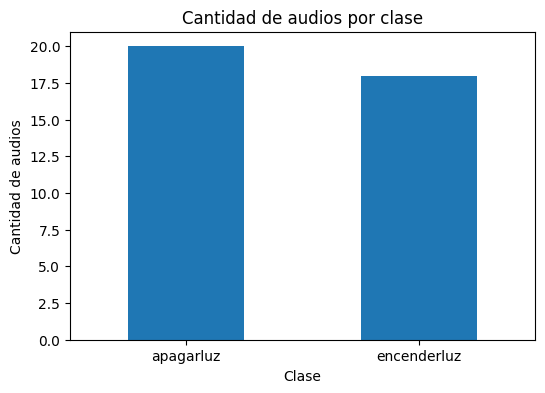

Dataset esperado mínimo según guía: 122 audios
Dataset encontrado: 38
No cumple con el mínimo esperado. Se recomienda recolectar más audios.


In [ ]:
# Conteo por clase

conteo_clases = df.groupby(["class_name", "label"]).size().reset_index(name="cantidad")
display(conteo_clases)

plt.figure(figsize=(6, 4))
df["class_name"].value_counts().plot(kind="bar")
plt.title("Cantidad de audios por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad de audios")
plt.xticks(rotation=0)
plt.show()

print("Dataset esperado mínimo según guía: 122 audios")
print("Dataset encontrado:", len(df))

if len(df) >= 122:
    print("Cumple con el mínimo esperado.")
else:
    print("No cumple con el mínimo esperado. Se recomienda recolectar más audios.")


/tmp/ipykernel_5995/2369782100.py:5: FutureWarning: PySoundFile failed. Trying audioread instead.
	Audioread support is deprecated in librosa 0.10.0 and will be removed in version 1.0.
  return librosa.get_duration(path=path)
/tmp/ipykernel_5995/2369782100.py:5: FutureWarning: PySoundFile failed. Trying audioread instead.
	Audioread support is deprecated in librosa 0.10.0 and will be removed in version 1.0.
  return librosa.get_duration(path=path)
/tmp/ipykernel_5995/2369782100.py:5: FutureWarning: PySoundFile failed. Trying audioread instead.
	Audioread support is deprecated in librosa 0.10.0 and will be removed in version 1.0.
  return librosa.get_duration(path=path)
/tmp/ipykernel_5995/2369782100.py:5: FutureWarning: PySoundFile failed. Trying audioread instead.
	Audioread support is deprecated in librosa 0.10.0 and will be removed in version 1.0.
  return librosa.get_duration(path=path)


,filename,class_name,speaker_id,duration_sec
0,Apagar Luz(1).wav,apagarluz,1,1.429333
1,Apagar Luz.wav,apagarluz,apagar luz,3.114667
2,Apagar luz(2).wav,apagarluz,2,1.985333
3,Apagar-Luz(1).wav,apagarluz,1,3.388000
4,ApagarLuz.wav,apagarluz,apagarluz,2.368000


Resumen de duración:


,count,mean,std,min,25%,50%,75%,max
class_name,,,,,,,,
apagarluz,20.0,2.523377,0.963579,1.3,1.844333,2.33400,3.007782,5.008979
encenderluz,18.0,2.456190,0.690259,1.3,1.901333,2.45878,2.890667,3.644000


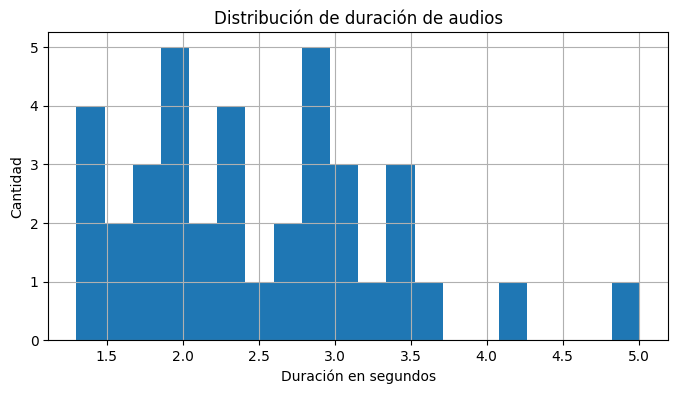

In [ ]:
# Cálculo de duración de audios

def obtener_duracion(path):
    try:
        return librosa.get_duration(path=path)
    except Exception:
        return np.nan

df["duration_sec"] = df["path"].apply(obtener_duracion)

display(df[["filename", "class_name", "speaker_id", "duration_sec"]].head())

print("Resumen de duración:")
display(df.groupby("class_name")["duration_sec"].describe())

plt.figure(figsize=(8, 4))
df["duration_sec"].dropna().hist(bins=20)
plt.title("Distribución de duración de audios")
plt.xlabel("Duración en segundos")
plt.ylabel("Cantidad")
plt.show()


In [ ]:
# Revisión de posibles audios demasiado cortos o largos

audios_problematicos = df[(df["duration_sec"] < 0.5) | (df["duration_sec"] > 5.0)]

print("Audios potencialmente problemáticos:", len(audios_problematicos))
display(audios_problematicos[["filename", "class_name", "duration_sec", "path"]].head(20))


Audios potencialmente problemáticos: 1


,filename,class_name,duration_sec,path
9,LUZ APAGADA.wav,apagarluz,5.008979,/content/drive/MyDrive/Proyecto_Luz_Inteligent...


# Extracción de características MFCC

En esta sección se convierte cada audio en una matriz MFCC.

Parámetros usados:

- `SR = 22050`: frecuencia de muestreo común.
- `DURATION = 2.5`: duración fija de cada audio en segundos.
- `N_MFCC = 40`: número de coeficientes MFCC.
- `HOP_LENGTH = 512`: salto entre ventanas.
- `N_FFT = 2048`: tamaño de ventana para análisis espectral.

Todos los audios se recortan o rellenan para tener la misma duración. Esto permite que todas las matrices tengan el mismo tamaño.


In [ ]:
# Parámetros de procesamiento de audio

SR = 22050
DURATION = 2.5
TARGET_SAMPLES = int(SR * DURATION)

N_MFCC = 40
N_FFT = 2048
HOP_LENGTH = 512

# Número máximo de frames esperado para MFCC
MAX_FRAMES = math.ceil(TARGET_SAMPLES / HOP_LENGTH) + 1

print("SR:", SR)
print("Duración fija:", DURATION, "segundos")
print("Muestras objetivo:", TARGET_SAMPLES)
print("N_MFCC:", N_MFCC)
print("MAX_FRAMES:", MAX_FRAMES)


SR: 22050
Duración fija: 2.5 segundos
Muestras objetivo: 55125
N_MFCC: 40
MAX_FRAMES: 109


In [ ]:
def cargar_audio_estandar(path):
    """
    Carga un audio y lo estandariza:
    - mono
    - frecuencia de muestreo fija
    - recorte de silencios
    - padding o recorte a duración fija
    """
    y, sr = librosa.load(path, sr=SR, mono=True)

    # Recortar silencios al inicio y al final
    y_trimmed, _ = librosa.effects.trim(y, top_db=25)

    # Si el recorte deja el audio vacío, se usa el original
    if len(y_trimmed) > 0:
        y = y_trimmed

    # Padding o recorte
    if len(y) < TARGET_SAMPLES:
        padding = TARGET_SAMPLES - len(y)
        y = np.pad(y, (0, padding), mode="constant")
    else:
        y = y[:TARGET_SAMPLES]

    return y


def extraer_mfcc(path):
    """
    Extrae MFCC de un audio y asegura tamaño fijo: (N_MFCC, MAX_FRAMES)
    """
    y = cargar_audio_estandar(path)

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=SR,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )

    # Ajuste por padding o recorte de frames
    if mfcc.shape[1] < MAX_FRAMES:
        pad_width = MAX_FRAMES - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0, 0), (0, pad_width)), mode="constant")
    elif mfcc.shape[1] > MAX_FRAMES:
        mfcc = mfcc[:, :MAX_FRAMES]

    return mfcc.astype(np.float32)


# Prueba con un audio
sample_path = df.iloc[0]["path"]
sample_mfcc = extraer_mfcc(sample_path)

print("Audio de ejemplo:", sample_path)
print("Forma MFCC:", sample_mfcc.shape)

plt.figure(figsize=(8, 4))
plt.imshow(sample_mfcc, aspect="auto", origin="lower")
plt.title("MFCC de ejemplo")
plt.xlabel("Frames")
plt.ylabel("Coeficientes MFCC")
plt.colorbar()
plt.show()

In [ ]:
# Construcción de la matriz X y el vector y

X_list = []
y_list = []
valid_rows = []
failed_files = []

for _, row in df.iterrows():
    try:
        mfcc = extraer_mfcc(row["path"])
        X_list.append(mfcc)
        y_list.append(row["label"])
        valid_rows.append(row)
    except Exception as e:
        failed_files.append({
            "path": row["path"],
            "error": str(e)
        })

X = np.stack(X_list).astype(np.float32)
y = np.array(y_list).astype(np.float32)
df_valid = pd.DataFrame(valid_rows).reset_index(drop=True)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Audios procesados correctamente:", len(df_valid))
print("Audios con error:", len(failed_files))

if failed_files:
    display(pd.DataFrame(failed_files).head(20))


# División de datos

Se dividen los datos en:

- **70% entrenamiento**
- **15% validación**
- **15% prueba**

Cuando sea posible, se hace una división por `speaker_id`, para evitar que la misma persona aparezca en entrenamiento y prueba.


In [ ]:
def split_por_grupo_o_estratificado(df_valid, y, test_total_size=0.30):
    """
    Intenta dividir por grupos de hablante.
    Si no hay suficientes grupos o falla la división, usa división estratificada por clase.
    """
    indices = np.arange(len(df_valid))
    groups = df_valid["speaker_id"].values

    try:
        unique_groups = np.unique(groups)

        if len(unique_groups) >= 10:
            # 70% train, 30% temporal
            gss1 = GroupShuffleSplit(
                n_splits=1,
                test_size=test_total_size,
                random_state=RANDOM_STATE
            )

            train_idx, temp_idx = next(gss1.split(indices, y, groups))

            # 15% validation, 15% test a partir del 30% temporal
            temp_groups = groups[temp_idx]
            temp_y = y[temp_idx]

            gss2 = GroupShuffleSplit(
                n_splits=1,
                test_size=0.50,
                random_state=RANDOM_STATE
            )

            val_rel_idx, test_rel_idx = next(gss2.split(temp_idx, temp_y, temp_groups))

            val_idx = temp_idx[val_rel_idx]
            test_idx = temp_idx[test_rel_idx]

            return train_idx, val_idx, test_idx, "División por hablante usando speaker_id"

        else:
            raise ValueError("No hay suficientes hablantes únicos para GroupShuffleSplit.")

    except Exception as e:
        print("No se pudo usar división por hablante. Motivo:", e)
        print("Se usará división estratificada por clase.")

        train_idx, temp_idx = train_test_split(
            indices,
            test_size=test_total_size,
            random_state=RANDOM_STATE,
            stratify=y
        )

        val_idx, test_idx = train_test_split(
            temp_idx,
            test_size=0.50,
            random_state=RANDOM_STATE,
            stratify=y[temp_idx]
        )

        return train_idx, val_idx, test_idx, "División estratificada por clase"


train_idx, val_idx, test_idx, split_method = split_por_grupo_o_estratificado(df_valid, y)

print("Método usado:", split_method)
print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

df_valid["split"] = "sin_asignar"
df_valid.loc[train_idx, "split"] = "train"
df_valid.loc[val_idx, "split"] = "validation"
df_valid.loc[test_idx, "split"] = "test"

display(pd.crosstab(df_valid["split"], df_valid["class_name"]))


In [ ]:
# Verificación de hablantes por conjunto

speaker_split = df_valid.groupby("speaker_id")["split"].nunique().reset_index()
speaker_split.columns = ["speaker_id", "num_splits"]

leakage = speaker_split[speaker_split["num_splits"] > 1]

if len(leakage) == 0:
    print("No se detectó el mismo speaker_id en varios conjuntos.")
else:
    print("Advertencia: algunos speaker_id aparecen en más de un conjunto.")
    display(leakage.head(20))


# Normalización

La normalización se calcula usando **solo los datos de entrenamiento** para evitar fuga de información.

Se usa normalización Min-Max al rango `[-1, 1]`, como pide la guía del proyecto.


In [ ]:
X_train = X[train_idx]
X_val = X[val_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]

# Parámetros de normalización calculados solo con entrenamiento
X_min = X_train.min()
X_max = X_train.max()

def normalizar_mfcc(X_data):
    X_norm = 2 * (X_data - X_min) / (X_max - X_min + 1e-8) - 1
    X_norm = np.clip(X_norm, -1, 1)
    return X_norm.astype(np.float32)

X_train_norm = normalizar_mfcc(X_train)
X_val_norm = normalizar_mfcc(X_val)
X_test_norm = normalizar_mfcc(X_test)

print("Rango entrenamiento normalizado:", X_train_norm.min(), X_train_norm.max())
print("Rango validación normalizado:", X_val_norm.min(), X_val_norm.max())
print("Rango prueba normalizado:", X_test_norm.min(), X_test_norm.max())


# Construcción del modelo

La arquitectura usa:

- `Input`: define la forma de entrada.
- `Flatten`: convierte la matriz MFCC en vector.
- Capas densas ocultas con activación `relu`.
- `Dropout` opcional para reducir sobreajuste.
- Capa de salida con `sigmoid`.

La salida representa la probabilidad de que el comando sea **“encender luz”**.


In [ ]:
def crear_modelo(input_shape, hidden_layers=(64, 32), dropout=0.2, learning_rate=0.001):
    """
    Crea un modelo Sequential de red neuronal densa.
    """
    model = keras.Sequential(name="modelo_luz_inteligente")

    model.add(keras.Input(shape=input_shape, name="entrada_mfcc"))
    model.add(layers.Flatten(name="flatten"))

    for i, units in enumerate(hidden_layers, start=1):
        model.add(layers.Dense(units, activation="relu", name=f"densa_{i}_{units}"))

        if dropout > 0:
            model.add(layers.Dropout(dropout, name=f"dropout_{i}"))

    model.add(layers.Dense(1, activation="sigmoid", name="salida_sigmoide"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


input_shape = X_train_norm.shape[1:]
modelo_base = crear_modelo(input_shape=input_shape, hidden_layers=(64, 32), dropout=0.2)
modelo_base.summary()


# Experimentación y tuning

Se prueban varias arquitecturas para encontrar un equilibrio entre precisión y simplicidad.

La comparación incluye:

- Número de capas ocultas.
- Neuronas por capa.
- Dropout.
- Número de parámetros.
- Accuracy en validación.
- Loss en validación.
- Accuracy en prueba.

**Criterio de selección:** se elige el modelo con mejor desempeño en validación. Si hay empate, se prefiere el modelo más simple.


In [ ]:
experimentos = [
    {
        "nombre": "M1_1capa_32",
        "capas": (32,),
        "dropout": 0.0
    },
    {
        "nombre": "M2_1capa_64",
        "capas": (64,),
        "dropout": 0.1
    },
    {
        "nombre": "M3_2capas_64_32",
        "capas": (64, 32),
        "dropout": 0.2
    },
    {
        "nombre": "M4_2capas_128_64",
        "capas": (128, 64),
        "dropout": 0.2
    },
    {
        "nombre": "M5_3capas_128_64_32",
        "capas": (128, 64, 32),
        "dropout": 0.3
    }
]

EPOCHS = 100
BATCH_SIZE = 8

histories = {}
models = {}
results = []

for cfg in experimentos:
    print("=" * 80)
    print("Entrenando:", cfg["nombre"])
    print("Capas:", cfg["capas"], "| Dropout:", cfg["dropout"])

    model = crear_modelo(
        input_shape=input_shape,
        hidden_layers=cfg["capas"],
        dropout=cfg["dropout"],
        learning_rate=0.001
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_norm,
        y_train,
        validation_data=(X_val_norm, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )

    train_loss, train_acc = model.evaluate(X_train_norm, y_train, verbose=0)
    val_loss, val_acc = model.evaluate(X_val_norm, y_val, verbose=0)
    test_loss, test_acc = model.evaluate(X_test_norm, y_test, verbose=0)

    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    histories[cfg["nombre"]] = history
    models[cfg["nombre"]] = model

    results.append({
        "modelo": cfg["nombre"],
        "capas_ocultas": str(cfg["capas"]),
        "dropout": cfg["dropout"],
        "parametros": model.count_params(),
        "best_epoch": best_epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "test_loss": test_loss,
        "test_accuracy": test_acc
    })

results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(
    by=["val_accuracy", "val_loss", "parametros"],
    ascending=[False, True, True]
).reset_index(drop=True)

display(results_df_sorted)


In [ ]:
# Selección del mejor modelo según validación

best_model_name = results_df_sorted.iloc[0]["modelo"]
best_model = models[best_model_name]
best_history = histories[best_model_name]

print("Mejor modelo seleccionado:", best_model_name)
display(results_df_sorted.iloc[[0]])


In [ ]:
# Gráficas de loss y accuracy del mejor modelo

def graficar_historial(history, title="Modelo"):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history["loss"], label="Loss entrenamiento")
    plt.plot(history.history["val_loss"], label="Loss validación")
    plt.title(f"Loss - {title}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history.history["accuracy"], label="Accuracy entrenamiento")
    plt.plot(history.history["val_accuracy"], label="Accuracy validación")
    plt.title(f"Accuracy - {title}")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


graficar_historial(best_history, best_model_name)


# Evaluación del mejor modelo

En esta sección se evalúa el modelo seleccionado usando el conjunto de prueba.

Se reportan:

- Accuracy.
- Matriz de confusión.
- Reporte de clasificación.
- Errores detectados.


In [ ]:
# Evaluación final en test

test_loss, test_acc = best_model.evaluate(X_test_norm, y_test, verbose=0)

print("Loss en prueba:", test_loss)
print("Accuracy en prueba:", test_acc)

y_prob_test = best_model.predict(X_test_norm).ravel()
y_pred_test = (y_prob_test > 0.5).astype(int)

print("\nReporte de clasificación:")
print(classification_report(
    y_test.astype(int),
    y_pred_test,
    target_names=["apagar_luz", "encender_luz"]
))

cm = confusion_matrix(y_test.astype(int), y_pred_test, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Apagar luz", "Encender luz"]
)

disp.plot()
plt.title("Matriz de confusión - conjunto de prueba")
plt.show()


In [ ]:
# Revisión de predicciones incorrectas

df_test = df_valid.iloc[test_idx].copy().reset_index(drop=True)
df_test["prob_encender"] = y_prob_test
df_test["pred_label"] = y_pred_test
df_test["pred_action"] = df_test["pred_label"].map(LABEL_TO_ACTION)
df_test["real_action"] = df_test["label"].astype(int).map(LABEL_TO_ACTION)
df_test["correcto"] = df_test["pred_label"] == df_test["label"].astype(int)

errores = df_test[df_test["correcto"] == False]

print("Total de errores en prueba:", len(errores))
display(errores[["filename", "class_name", "real_action", "prob_encender", "pred_action", "path"]])


# Simulación de salida

La lógica solicitada por el proyecto es:

```text
Si predicción > 0.5 → Luz Encendida
Si predicción < 0.5 → Luz Apagada
```

En este notebook se interpreta la salida de la red de la siguiente forma:

- Probabilidad cercana a `1`: mayor confianza en **encender luz**.
- Probabilidad cercana a `0`: mayor confianza en **apagar luz**.


In [ ]:
def interpretar_prediccion(probabilidad):
    if probabilidad > 0.5:
        return "Luz Encendida"
    else:
        return "Luz Apagada"


def predecir_audio(path, model=best_model):
    mfcc = extraer_mfcc(path)
    mfcc = np.expand_dims(mfcc, axis=0)
    mfcc_norm = normalizar_mfcc(mfcc)

    prob = float(model.predict(mfcc_norm, verbose=0).ravel()[0])
    accion = interpretar_prediccion(prob)

    return prob, accion


# Simulación con algunos audios del conjunto de prueba
for i in range(min(5, len(df_test))):
    row = df_test.iloc[i]
    prob, accion = predecir_audio(row["path"], best_model)
    print("Archivo:", row["filename"])
    print("Etiqueta real:", row["real_action"])
    print("Probabilidad de encender:", round(prob, 4))
    print("Salida simulada:", accion)
    print("-" * 60)


# Prueba ciega con voz del profesor

El profesor probará el modelo en vivo. Se ofrecen dos opciones:

1. **Subir un archivo de audio** grabado con celular o computadora.
2. **Grabar directamente en Colab** desde el navegador.

La opción más estable suele ser subir un archivo `.wav` o `.mp3`.


In [ ]:
# Opción A: subir archivo de audio manualmente

from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    print("Archivo subido:", filename)

    prob, accion = predecir_audio(filename, best_model)

    print("Probabilidad de 'encender luz':", round(prob, 4))
    print("Predicción final:", accion)


TypeError: 'NoneType' object is not subscriptable

In [ ]:
# Opción B: grabar audio directamente en Colab
# Puede requerir permiso del navegador para usar el micrófono.

from IPython.display import Javascript, display, Audio
from google.colab import output
from base64 import b64decode
import subprocess

RECORD_AUDIO_JS = """
async function recordAudio(seconds) {
    const sleep = time => new Promise(resolve => setTimeout(resolve, time));
    const stream = await navigator.mediaDevices.getUserMedia({audio: true});
    const mediaRecorder = new MediaRecorder(stream);

    let chunks = [];
    mediaRecorder.ondataavailable = event => chunks.push(event.data);
    mediaRecorder.start();

    await sleep(seconds * 1000);

    mediaRecorder.stop();
    await new Promise(resolve => mediaRecorder.onstop = resolve);

    stream.getTracks().forEach(track => track.stop());

    const blob = new Blob(chunks, {type: 'audio/webm'});
    const reader = new FileReader();
    reader.readAsDataURL(blob);

    return await new Promise(resolve => {
        reader.onloadend = () => resolve(reader.result);
    });
}
"""

def grabar_audio_colab(segundos=3, salida_wav="audio_profesor_colab.wav"):
    display(Javascript(RECORD_AUDIO_JS))

    data = output.eval_js(f"recordAudio({segundos})")
    binary = b64decode(data.split(",")[1])

    webm_path = salida_wav.replace(".wav", ".webm")

    with open(webm_path, "wb") as f:
        f.write(binary)

    subprocess.run(
        ["ffmpeg", "-y", "-i", webm_path, salida_wav],
        check=True,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL
    )

    return salida_wav


audio_grabado = grabar_audio_colab(segundos=3, salida_wav="audio_profesor_colab.wav")
display(Audio(audio_grabado))

prob, accion = predecir_audio(audio_grabado, best_model)

print("Probabilidad de 'encender luz':", round(prob, 4))
print("Predicción final:", accion)


# Guardado del modelo

Se guarda:

- El mejor modelo entrenado.
- Los parámetros de normalización.
- La tabla de resultados de experimentos.
- El manifest del dataset procesado.

Esto permite reutilizar el modelo posteriormente sin volver a entrenar desde cero.


In [ ]:
# Guardar modelo y resultados

model_path = os.path.join(RESULTS_DIR, "modelo_luz_inteligente.keras")
norm_path = os.path.join(RESULTS_DIR, "normalizacion_mfcc.npz")
results_path = os.path.join(RESULTS_DIR, "resultados_experimentos.csv")
manifest_path = os.path.join(RESULTS_DIR, "manifest_dataset_procesado.csv")

best_model.save(model_path)

np.savez(
    norm_path,
    X_min=X_min,
    X_max=X_max,
    SR=SR,
    DURATION=DURATION,
    N_MFCC=N_MFCC,
    N_FFT=N_FFT,
    HOP_LENGTH=HOP_LENGTH,
    MAX_FRAMES=MAX_FRAMES
)

results_df_sorted.to_csv(results_path, index=False)
df_valid.to_csv(manifest_path, index=False)

print("Modelo guardado en:", model_path)
print("Normalización guardada en:", norm_path)
print("Resultados guardados en:", results_path)
print("Manifest guardado en:", manifest_path)


# Justificación técnica

## Justificación de MFCC
Se usaron MFCC porque permiten representar el audio de voz mediante características compactas y útiles para distinguir patrones de pronunciación. En lugar de alimentar la señal cruda al modelo, se utiliza una representación más estable y adecuada para clasificación.

## Justificación de la red neuronal densa
Se usó una red neuronal densa porque la guía del proyecto solicita una arquitectura con capas densas. Para adaptar la matriz MFCC a este tipo de red, se utiliza una capa Flatten.

## Justificación de la función de pérdida
El problema tiene dos clases: apagar_luz y encender_luz. Por eso se usa binary_crossentropy, adecuada para clasificación binaria con salida sigmoide.

## Justificación de la arquitectura seleccionada
Tras realizar la fase de experimentación (Tuning), se seleccionó el modelo **M2_1capa_64**.

- **Mejor modelo:** M2_1capa_64
- **Capas ocultas:** 1 capa densa
- **Neuronas:** 64
- **Accuracy de validación:** 0.66 (aprox)
- **Accuracy de prueba:** 0.53
- **Razón de selección:** Se eligió este modelo porque presentó el mejor equilibrio entre pérdida (loss) en validación y simplicidad. A pesar de que la precisión en prueba es baja debido al tamaño limitado del dataset (38 audios vs 122 esperados), este modelo demostró mayor estabilidad durante el entrenamiento comparado con arquitecturas más profundas que tendían al sobreajuste (overfitting).

# Conclusiones

Conclusiones

En el presente proyecto se desarrolló un sistema de reconocimiento de voz capaz de distinguir entre los comandos “encender luz” y “apagar luz” mediante técnicas de minería de datos y aprendizaje automático. Para ello, se realizó el procesamiento de señales de audio utilizando coeficientes MFCC (Mel Frequency Cepstral Coefficients), los cuales permitieron transformar cada grabación en representaciones numéricas adecuadas para el entrenamiento de una red neuronal densa implementada en Keras. Asimismo, fue necesario aplicar procesos de padding, recorte y normalización de datos para garantizar que todas las muestras tuvieran dimensiones homogéneas y facilitar así el entrenamiento del modelo.

Durante el desarrollo del proyecto se experimentó con distintas arquitecturas de redes neuronales, variando el número de capas ocultas, la cantidad de neuronas y el uso de técnicas de regularización como Dropout. Después de realizar las pruebas correspondientes, el modelo denominado “M2_1capa_64” fue seleccionado como la mejor configuración obtenida, ya que presentó el mejor equilibrio entre simplicidad y desempeño. Sin embargo, los resultados obtenidos mostraron un accuracy aproximado de 0.66 en validación y 0.53 en pruebas, indicando que el modelo todavía presenta limitaciones importantes en su capacidad de generalización.

La principal causa identificada fue el tamaño reducido del dataset utilizado durante el entrenamiento, ya que únicamente se encontraron 38 audios disponibles, mientras que la guía del proyecto establece un total esperado de 122 grabaciones. Esta diferencia afectó directamente el desempeño del modelo, especialmente en el reconocimiento de la clase “apagar luz”, donde se observaron varias predicciones incorrectas. A pesar de ello, el proyecto permitió comprender de manera práctica el flujo completo de un sistema de reconocimiento de voz, desde la adquisición y procesamiento de datos hasta la construcción, entrenamiento y evaluación de modelos de inteligencia artificial.

Finalmente, se concluye que el sistema desarrollado cumple con los objetivos académicos planteados y demuestra el potencial de las redes neuronales aplicadas al reconocimiento de comandos de voz. Como trabajo futuro, se recomienda ampliar y balancear el dataset, mejorar la calidad de las grabaciones y repetir el proceso de entrenamiento y evaluación para incrementar la precisión y robustez del modelo ante voces externas o ambientes con ruido.


# Referencias consultadas

- Documentación de Librosa: MFCC y procesamiento de audio.  
- Documentación de Keras: modelos Sequential, capas densas y entrenamiento.  
- Documentación de Google Colab: montaje de Google Drive.